# Model Performance: MSE and NLL
Distribution of cross-validated loss (MSE for carrabin and yoo,
NLL for jiang) across participants for each model and task.
One panel per task, 1 row × 3 columns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
sys.path.insert(0, str(Path('..').resolve()))
from utils.paths import data_path
from utils.plot_style import apply_style
from statannotations.Annotator import Annotator
from itertools import combinations

In [2]:
apply_style()
palette = sns.color_palette("colorblind")
# colors assigned by model role, consistent across tasks:
# optimal (Bayes, Mean) = palette[0]
# naive (RL) = palette[1]
# human-matching (NoisyCounting, DeGroot, ADM) = palette[2]
PALETTE = {
    'Bayes':         palette[0],
    'Mean':          palette[0],
    'RL':            palette[1],
    'NoisyCounting': palette[2],
    'DeGroot':       palette[2],
    'ADM':           palette[2],
}
MODEL_ORDER = {
    'carrabin': ['Bayes', 'RL', 'NoisyCounting'],
    'jiang':    ['Bayes', 'RL', 'DeGroot'],
    'yoo':      ['Mean', 'RL', 'ADM'],
}
YLABELS = {
    'carrabin': 'MSE',
    'jiang':    'NLL',
    'yoo':      'MSE',
}
TITLES = {
    'carrabin': 'Ratio Estimation',
    'jiang':    'Social Learning',
    'yoo':      'Value Comparison',
}

In [3]:
run_folder = "MSE"
run_dir = data_path("runs") / run_folder

DEFAULT_LOSS = {"carrabin": "mse", "jiang": "nll", "yoo": "mse"}

dfs = []
for dataset, models in MODEL_ORDER.items():
    for model_type in models:
        f = run_dir / f"{model_type}_{dataset}_performance.pkl"
        if f.exists():
            dfs.append(pd.read_pickle(f))
        else:
            print(f"Missing: {f.name}")

perf = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Bayes vs. RL: Wilcoxon test (paired samples), P_val:6.281e-03 Stat=3.900e+01
RL vs. NoisyCounting: Wilcoxon test (paired samples), P_val:1.907e-06 Stat=1.000e+00
Bayes vs. NoisyCounting: Wilcoxon test (paired samples), P_val:2.861e-06 Stat=2.000e+00
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Bayes vs. RL: Wilcoxon test (paired samples), P_val:6.116e-31 Stat=8.480e+02
RL vs. DeGroot: Wilcoxon test (paired samples), P_val:1.906e-35 Stat=9.600e+01
Bayes vs. DeGroot: Wilcoxon test (paired samples), P_val:8.072e-36 Stat=3.600e+01
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e

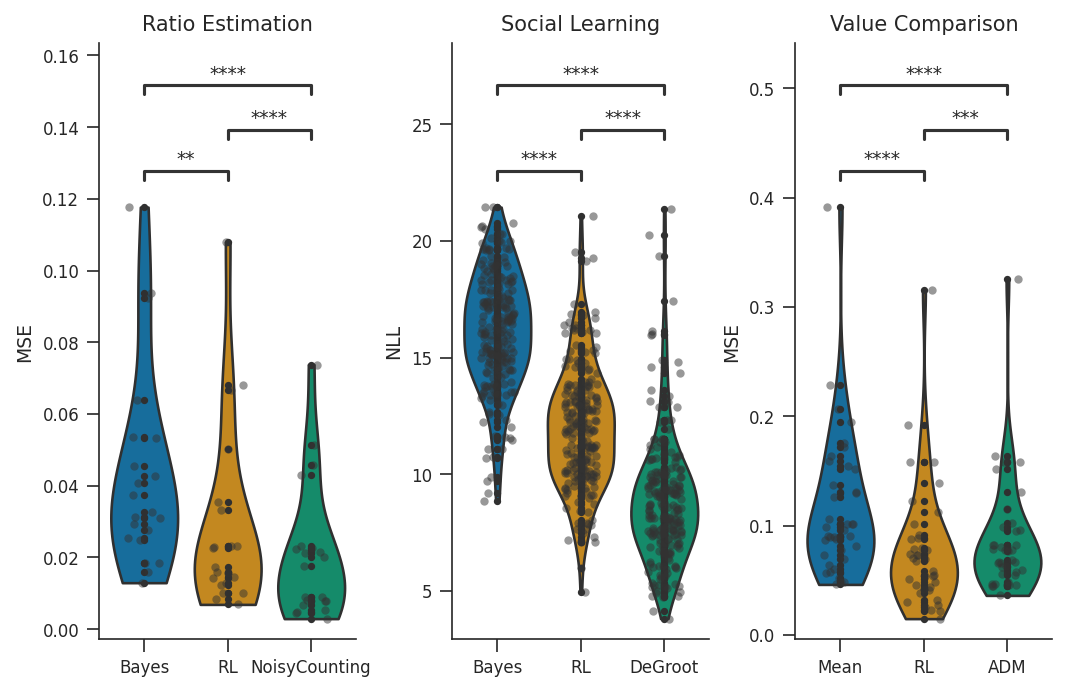

In [4]:
proj = Path("..").resolve()
fig_dir = proj / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 3, constrained_layout=True)
for ax, dataset in zip(axes, ["carrabin", "jiang", "yoo"]):
    subset = perf[perf["dataset"] == dataset]
    order = MODEL_ORDER[dataset]
    if subset.empty:
        ax.set_title(TITLES[dataset])
        ax.text(
            0.5,
            0.5,
            "no data",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )
        sns.despine(ax=ax, top=True, right=True)
        continue
    sns.violinplot(
        data=subset,
        x="model_type",
        y="cv_loss_mean",
        order=order,
        hue="model_type",
        palette=PALETTE,
        inner="point",
        legend=False,
        cut=0,
        ax=ax,
    )
    np.random.seed(42)
    sns.stripplot(
        data=subset,
        x="model_type",
        y="cv_loss_mean",
        order=order,
        color="0.2",
        alpha=0.5,
        jitter=0.2,
        size=4,
        ax=ax,
    )
    ax.set_title(TITLES[dataset])
    ax.set_ylabel(YLABELS[dataset])
    ax.set_xlabel("")
    sns.despine(ax=ax, top=True, right=True)
    pairs = list(combinations(order, 2))
    annotator = Annotator(ax, pairs, data=subset, x='model_type', 
                         y='cv_loss_mean', order=order)
    annotator.configure(test='Wilcoxon', text_format='star', loc='inside')
    annotator.apply_and_annotate()

plt.savefig(fig_dir / "performance_mse_nll.png", dpi=300)
plt.savefig(fig_dir / "performance_mse_nll.pdf")
plt.show()